# Multifrequency SVD-Subspace Map-Making Demo

Constrains the multifrequency sky $a_{\ell m}(\nu)$ to live in
$\mathrm{span}(\{f_k(\nu)\}) \otimes \text{alm-space}$, where $\{f_k\}_{k=0}^{K-1}$
are the leading frequency-SVD modes of the ULSA cube. The solve has $K$ single-frequency
maps as unknowns instead of $n_\text{freq}\cdot n_\text{alm}$.

For foreground-dominated data this is an aggressive but physically motivated prior:
the sky is almost entirely captured by ~3 spectrally smooth modes.

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import time
import jax, jax.numpy as jnp
import numpy as np
import lusee
from lusee import mapmaker as mm
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline

The croissant.jax interface is deprecated and will be removed in a future release. Please use the croissant interface directly instead.


In [2]:
DRIVE = os.environ.get("LUSEE_DRIVE_DIR", "/fs/zack/LuSEE-Night/")
BEAM_FILE = DRIVE + "Simulations/BeamModels/LanderRegolithComparison/eight_layer_regolith/hfss_lbl_3m_75deg.fits"
SKY_FILE  = DRIVE + "Simulations/SkyModels/ULSA_32_ddi_smooth.fits"

LMAX = 6
K    = 3
FREQ = np.array([15.0, 20.0, 25.0, 30.0, 35.0, 40.0])
OBS_RANGE = "2025-02-01 13:00:00 to 2025-02-14 13:00:00" 

## Extract SVD frequency templates from ULSA

Singular values: [20292411.99125071   766440.08400896    86020.85202775]
Ratio σ_2/σ_0 = 3.78e-02,  σ_3/σ_0 = 4.24e-03


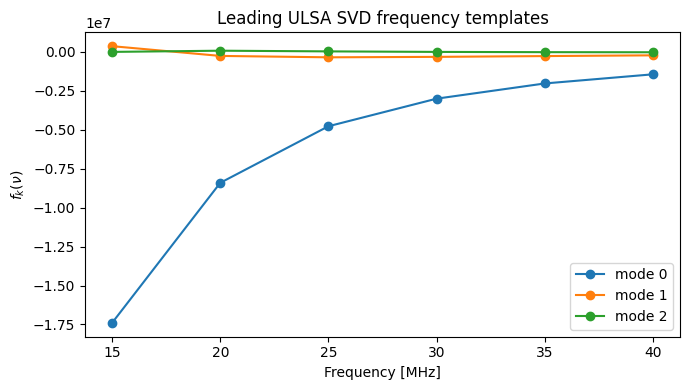

In [3]:
F, spatial, sv = mm.compute_ulsa_svd(SKY_FILE, FREQ, K=K, lmax=LMAX)
print(f"Singular values: {sv}")
print(f"Ratio σ_2/σ_0 = {sv[1]/sv[0]:.2e},  σ_3/σ_0 = {sv[2]/sv[0]:.2e}")

fig, ax = plt.subplots(figsize=(7, 4))
for k in range(K):
    ax.plot(FREQ, F[:, k], 'o-', label=f"mode {k}")
ax.set_xlabel("Frequency [MHz]"); ax.set_ylabel("$f_k(\\nu)$")
ax.legend(); ax.set_title("Leading ULSA SVD frequency templates"); plt.tight_layout()

## Build instrument and simulate data from ULSA

In [4]:
sim, beams, obs = mm.build_instrument(
    beam_file=BEAM_FILE, obs_range=OBS_RANGE, freq=FREQ, lmax=LMAX, dt_sec=7200.0,
)
sky_full = lusee.sky.FitsSky(SKY_FILE, lmax=LMAX)
sky_freq = np.asarray(sky_full.freq, dtype=float)
idx = np.array([int(np.argmin(np.abs(sky_freq - f))) for f in FREQ])
maps = np.asarray(sky_full.maps)[idx]
sky = lusee.sky.HealpixSky(sky_full.Nside, LMAX, maps=[m for m in maps],
                            freq=FREQ, frame="galactic")
data_clean = sim.simulate(sky=sky)
sigma = mm.compute_radiometric_noise(data_clean, delta_f_hz=1e6, delta_t_sec=7200.0)
data = data_clean + sigma * jax.random.normal(jax.random.PRNGKey(3), data_clean.shape)
print(f"{len(obs.times)} timesteps, {data.shape[1]} channels, {len(FREQ)} freqs")

  intializing beam combination N x N ...


  intializing beam combination E x E ...
  intializing beam combination S x S ...


  intializing beam combination W x W ...
  intializing beam combination N x S ...
    cross power is 0.0 ... 0.0 


  intializing beam combination E x W ...
    cross power is 0.0 ... 0.0 
  intializing beam combination N x E ...


    cross power is 0.0 ... 0.0 
  intializing beam combination E x S ...
    cross power is 0.0 ... 0.0 
  intializing beam combination N x W ...


    cross power is 0.0 ... 0.0 
  intializing beam combination S x W ...
    cross power is 0.0 ... 0.0 


158 timesteps, 16 channels, 6 freqs


## Prior on $\beta_k$

For each SVD mode $k$, use the angular power spectrum of its spatial map as
the prior variance: $S^{-1}_k(\ell) = 1/C_\ell[m_k]$.

In [5]:
nalm = hp.Alm.getsize(LMAX)
S_inv_beta = np.zeros((K, nalm))
for k in range(K):
    alm_k = hp.map2alm(spatial[k], lmax=LMAX)
    cl = hp.alm2cl(alm_k)
    for l in range(LMAX + 1):
        for m in range(l + 1):
            if cl[l] > 0:
                S_inv_beta[k, hp.Alm.getidx(LMAX, l, m)] = 1.0 / cl[l]
S_inv_beta = jnp.asarray(S_inv_beta)

## SVD-subspace solve vs full freq-by-freq CG

In [6]:
t0 = time.time()
beta_hat = mm.solve_svd_multifreq(
    sim, data, sky, sigma, F, signal_prior=S_inv_beta, lmax=LMAX,
    maxiter=1000, tol=1e-10,
)
t_svd = time.time() - t0
rec_alm_svd = np.asarray(jnp.asarray(F) @ beta_hat)
print(f"SVD-subspace solve: {t_svd:.1f}s  ({K} beta maps, n_theta = {beta_hat.size})")

t0 = time.time()
S_inv_full = mm.compute_cl_prior(sky, LMAX)
alm_full = mm.solve(sim, data, sky, sigma, signal_prior=S_inv_full,
                    maxiter=1000, tol=1e-10)
t_full = time.time() - t0
alm_full = np.asarray(alm_full)
print(f"Full freq-by-freq CG: {t_full:.1f}s")

SVD-subspace solve: 53.1s  (3 beta maps, n_theta = 84)


Full freq-by-freq CG: 40.7s


## Reconstruction fidelity per frequency

mean rho per freq:
   15.0 MHz:  SVD=0.9995   full=0.9882
   20.0 MHz:  SVD=0.9998   full=0.9953
   25.0 MHz:  SVD=0.9999   full=0.9999
   30.0 MHz:  SVD=1.0000   full=1.0000
   35.0 MHz:  SVD=1.0000   full=1.0000
   40.0 MHz:  SVD=1.0000   full=1.0000


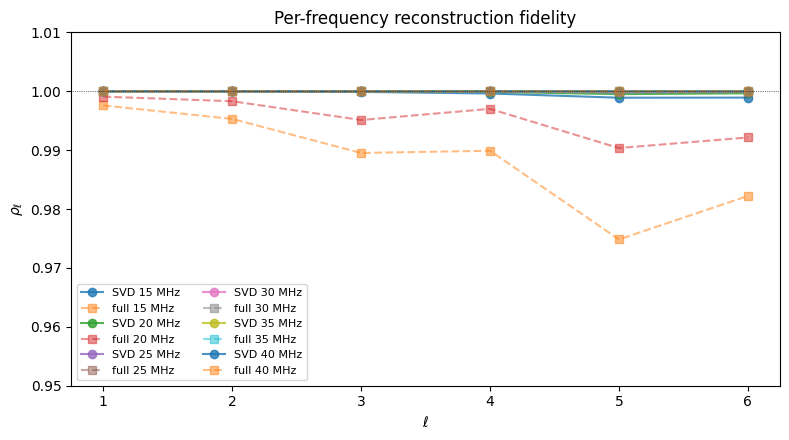

In [7]:
def rho_per_ell(true_alm, rec):
    cl_t = hp.alm2cl(true_alm); cl_r = hp.alm2cl(rec)
    return hp.alm2cl(true_alm, rec) / np.sqrt(cl_t * cl_r + 1e-30)

fig, ax = plt.subplots(figsize=(8, 4.5))
means_svd, means_full = [], []
for fi, f in enumerate(FREQ):
    true = np.asarray(sky.mapalm[fi])
    r_svd  = rho_per_ell(true, rec_alm_svd[fi])
    r_full = rho_per_ell(true, alm_full[fi])
    ax.plot(np.arange(LMAX+1)[1:], r_svd[1:LMAX+1], 'o-', label=f"SVD {f:.0f} MHz", alpha=0.8)
    ax.plot(np.arange(LMAX+1)[1:], r_full[1:LMAX+1], 's--', label=f"full {f:.0f} MHz", alpha=0.5)
    means_svd.append(float(np.nanmean(r_svd[1:LMAX+1])))
    means_full.append(float(np.nanmean(r_full[1:LMAX+1])))
ax.axhline(1, color='k', lw=0.5, ls=':')
ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$\rho_\ell$")
ax.set_ylim(0.95, 1.01)
ax.legend(ncol=2, fontsize=8); ax.set_title("Per-frequency reconstruction fidelity")
plt.tight_layout()

print("mean rho per freq:")
for f, a, b in zip(FREQ, means_svd, means_full):
    print(f"  {f:5.1f} MHz:  SVD={a:.4f}   full={b:.4f}")

## When SVD-subspace wins

At low frequencies where the ionosphere-free sky is dominated by only a few
spectrally smooth modes, the $K=3$ subspace constraint acts as a strong prior
and beats unconstrained CG. The benefit diminishes as $K \to n_\text{freq}$ or
when spectrally non-smooth residuals (e.g. 21-cm signal) become comparable to the
foreground — in that regime use a larger $K$ or fall back to `mm.solve`.